<a href="https://colab.research.google.com/github/valeriesutanta/pcol3911/blob/main/Copy_of_Optional_ModellingFlowExampleFromJACS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ChatGPT Chemistry Assistant**

Please check out https://pubs.acs.org/doi/10.1021/jacs.3c05819 for more details.

The main parts of the script below are from their repo but changes / extensions have been made to clarify what's happening.

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             roc_auc_score, balanced_accuracy_score)

In [ ]:
import numpy as np
import pandas as pd
from copy import deepcopy

In [ ]:
#Load data from Github
data = pd.read_csv("https://github.com/sladem-tox/Tox_data/raw/main/OP_desc.csv")

In [ ]:
data.columns

Index(['ID', 'SMILES', 'Expr', 'nAcid', 'nBase', 'SpAbs_A', 'SpMax_A',
       'SpDiam_A', 'SpAD_A', 'SpMAD_A',
       ...
       'SRW10', 'TSRW10', 'MW', 'AMW', 'WPath', 'WPol', 'Zagreb1', 'Zagreb2',
       'mZagreb1', 'mZagreb2'],
      dtype='object', length=1483)

In [ ]:
data["Expr"].median() #Need a more biologically relevant border really but this will give a good split of the data

5.18

In [ ]:
data["result"] = (data["Expr"] > 5.18).astype(int) #Here we assign a class to molecules based on their binding value

In [ ]:
data.drop(columns=["ID", "SMILES", "Expr"], inplace=True)

In [ ]:
data.columns

Index(['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDiam_A', 'SpAD_A', 'SpMAD_A',
       'LogEE_A', 'VE1_A', 'VE2_A',
       ...
       'TSRW10', 'MW', 'AMW', 'WPath', 'WPol', 'Zagreb1', 'Zagreb2',
       'mZagreb1', 'mZagreb2', 'result'],
      dtype='object', length=1481)

In [ ]:
# preprocess data and drop unused columns

#data = pd.read_csv("processed_data.csv") # from their data
t_ys = data["result"].values
Xs = data.drop(["result"], axis=1).fillna(0.)
nan_mask = np.all(data == 0, axis=0)
t_Xs = Xs.drop(list(data.columns[nan_mask]), axis=1)

In [ ]:
# held-out set
Xs, hXs, ys, hys = train_test_split(t_Xs,t_ys, train_size=0.8, random_state=49, stratify=t_ys)

In [ ]:
# recursive feature reduction

clf = RandomForestClassifier(criterion="entropy", random_state=49, class_weight="balanced")
rfecv = RFECV(
    estimator=clf,
    cv=5,
    scoring="accuracy",
    min_features_to_select=20,
)
rfecv.fit(Xs.values, ys)

print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 328


In [ ]:
# Edit: the code as it was did not print the names of the best features
# Since it takes an hour to run we want to save them!
# Save the list of the best feature names
best_features = Xs.columns[rfecv.support_]
best_features_df = pd.DataFrame(best_features, columns=["Best_Features"])

# Print the list of best features
print("Best features:")
print(best_features)

# Optionally save the list to a file (e.g., CSV or text file)
best_features_df.to_csv("best_features.csv", index=False)

Best features:
Index(['ATS5i', 'AATS0dv', 'AATS1dv', 'AATS3dv', 'AATS4dv', 'AATS5dv',
       'AATS6dv', 'AATS8dv', 'AATS0d', 'AATS1d',
       ...
       'MDEC-12', 'MDEC-23', 'MID_h', 'MID_O', 'TMPC10', 'piPC5', 'piPC8',
       'TpiPC10', 'RotRatio', 'GGI1'],
      dtype='object', length=328)


In [ ]:
train_size = np.arange(0.4, 1, 0.1)
X_REF = Xs.values[:, rfecv.support_] # here we select the best descriptors from above
params = {"n_estimators": np.arange(50, 250, 50),
            "min_samples_leaf": np.arange(5, 30)}
REF_ac = {"train": [], "test": [], "held out": [], "f1": [], "p": [], "r": [], "auc": []}
prev = 0
prev_test = 0

np.random.seed(49)
split_states = np.random.randint(100, size=10)

for s in train_size:
    print(f"Running for train_size = {s}")  # Add this line to check progress
    train_ac = np.zeros(10)
    test_ac = np.zeros(10)
    held_ac = np.zeros(10)
    test_F1 = np.zeros(20)
    test_p = np.zeros(20)
    test_r = np.zeros(20)
    test_auc = np.zeros(20)
    X_train, X_test, y_train, y_test = train_test_split(X_REF, ys, train_size=s, random_state=49)
    for i, si in enumerate(split_states):
        print(f"Running for split state {i}, random_state {si}")
        # hyperparameter tunning
        rf = RandomForestClassifier(criterion="entropy", random_state=49, class_weight="balanced")
        clf = RandomizedSearchCV(rf, params, n_iter=10, random_state=si)
        search = clf.fit(X_train, y_train)

        #print(search.best_params_)
        best_rf = clf.best_estimator_

        test_pred = best_rf.predict(X_test)
        htest_pred = best_rf.predict(hXs.values[:, rfecv.support_])
        train_pred = best_rf.predict(X_train)
        test_ac[i] = balanced_accuracy_score(y_test, test_pred)
        held_ac[i] = balanced_accuracy_score(hys, htest_pred)
        if test_ac[-1] > prev_test:
            prev_test = test_ac[-1]
            best_test_model = deepcopy(best_rf)
        if held_ac[-1] > prev:
            prev = held_ac[-1]
            best_model = deepcopy(best_rf)

        #print(f"seed {i}, balanced accuracy {test_ac[-1]}, accuracy {best_rf.score(X_test, y_test)}")
        test_F1[2*i] = f1_score(y_test, test_pred)
        test_p[2*i] = precision_score(y_test, test_pred)
        test_r[2*i] = recall_score(y_test, test_pred)
        test_auc[2*i] = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
        train_ac[i] = balanced_accuracy_score(y_train, train_pred)

        test_F1[2*i+1] = f1_score(hys, htest_pred)
        test_p[2*i+1] = precision_score(hys, htest_pred)
        test_r[2*i+1] = recall_score(hys, htest_pred)
        test_auc[2*i+1] = roc_auc_score(hys, best_rf.predict_proba(hXs.values[:, rfecv.support_])[:, 1])

    REF_ac["train"] += [train_ac]
    REF_ac["test"] += [test_ac]
    REF_ac["held out"] += [held_ac]
    REF_ac["f1"] += [test_F1[0::2], test_F1[1::2]]
    REF_ac["p"] += [test_p[0::2], test_p[1::2]]
    REF_ac["r"] += [test_r[0::2], test_r[1::2]]
    REF_ac["auc"] += [test_auc[0::2], test_auc[1::2]]
print("Finished processing, showing results:")
print(REF_ac)

In [ ]:
print(search.best_params_)

{'n_estimators': 150, 'min_samples_leaf': 5}


In [ ]:
import joblib
joblib.dump(best_model, "best_random_forest_model.pkl")
print("Model saved as best_random_forest_model.pkl")

Model saved as best_random_forest_model.pkl


In [ ]:
for key, value in REF_ac.items():
    print(f"{key}: {len(value)}")

train: 6
test: 6
held out: 6
f1: 12
p: 12
r: 12
auc: 12


In [ ]:
print(REF_ac["held out"])

[array([0.82142857, 0.82142857, 0.78571429, 0.78571429, 0.83928571,
       0.83928571, 0.75      , 0.82142857, 0.82142857, 0.75      ]), array([0.82142857, 0.82142857, 0.82142857, 0.73214286, 0.80357143,
       0.76785714, 0.75      , 0.82142857, 0.80357143, 0.83928571]), array([0.83928571, 0.83928571, 0.82142857, 0.78571429, 0.82142857,
       0.82142857, 0.82142857, 0.83928571, 0.83928571, 0.82142857]), array([0.80357143, 0.82142857, 0.78571429, 0.78571429, 0.78571429,
       0.78571429, 0.78571429, 0.82142857, 0.80357143, 0.80357143]), array([0.83928571, 0.875     , 0.83928571, 0.83928571, 0.83928571,
       0.82142857, 0.83928571, 0.875     , 0.83928571, 0.875     ]), array([0.83928571, 0.85714286, 0.76785714, 0.82142857, 0.83928571,
       0.80357143, 0.83928571, 0.85714286, 0.82142857, 0.85714286])]


In [ ]:
# Now to make predictions with best_model on test data and held-out data
# to get performance metrics
test_pred_best_model = best_model.predict(X_test)
htest_pred_best_model = best_model.predict(hXs.values[:, rfecv.support_])

# Compute metrics for the best model on the test and held-out data
test_ac_best_model = balanced_accuracy_score(y_test, test_pred_best_model)
held_ac_best_model = balanced_accuracy_score(hys, htest_pred_best_model)

test_F1_best_model = f1_score(y_test, test_pred_best_model)
test_p_best_model = precision_score(y_test, test_pred_best_model)
test_r_best_model = recall_score(y_test, test_pred_best_model)
test_auc_best_model = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

held_F1_best_model = f1_score(hys, htest_pred_best_model)
held_p_best_model = precision_score(hys, htest_pred_best_model)
held_r_best_model = recall_score(hys, htest_pred_best_model)
held_auc_best_model = roc_auc_score(hys, best_model.predict_proba(hXs.values[:, rfecv.support_])[:, 1])

# Print the metrics for the best model
print(f"Performance metrics for best model:")
print(f"Test Set - Balanced Accuracy: {test_ac_best_model:.3f}")
print(f"Test Set - F1 Score: {test_F1_best_model:.3f}")
print(f"Test Set - Precision: {test_p_best_model:.3f}")
print(f"Test Set - Recall: {test_r_best_model:.3f}")
print(f"Test Set - AUC: {test_auc_best_model:.3f}")

print(f"Held Out Set - Balanced Accuracy: {held_ac_best_model:.3f}")
print(f"Held Out Set - F1 Score: {held_F1_best_model:.3f}")
print(f"Held Out Set - Precision: {held_p_best_model:.3f}")
print(f"Held Out Set - Recall: {held_r_best_model:.3f}")
print(f"Held Out Set - AUC: {held_auc_best_model:.3f}")

Performance metrics for best model:
Test Set - Balanced Accuracy: 0.837
Test Set - F1 Score: 0.846
Test Set - Precision: 0.917
Test Set - Recall: 0.786
Test Set - AUC: 0.889
Held Out Set - Balanced Accuracy: 0.875
Held Out Set - F1 Score: 0.868
Held Out Set - Precision: 0.920
Held Out Set - Recall: 0.821
Held Out Set - AUC: 0.944


   Train Size  Train Mean  Train Std  Test Mean  Test Std  Held Out Mean  \
0         0.4    0.940503   0.045594   0.786854  0.027429       0.803571   
1         0.5    0.933018   0.033319   0.771053  0.012332       0.798214   
2         0.6    0.941493   0.028545   0.780682  0.022376       0.825000   
3         0.7    0.931056   0.028438   0.757946  0.012584       0.798214   
4         0.8    0.929774   0.032868   0.794433  0.023902       0.848214   
5         0.9    0.932343   0.025338   0.781746  0.000000       0.830357   

   Held Out Std   F1 Mean    F1 Std  Precision Mean  Precision Std  \
0      0.031944  0.772893  0.027380        0.837958       0.037530   
1      0.033929  0.795464  0.027480        0.835341       0.052985   
2      0.015567  0.749828  0.011273        0.842941       0.021658   
3      0.013947  0.792143  0.025620        0.825560       0.061059   
4      0.018298  0.750428  0.020478        0.868494       0.047606   
5      0.026786  0.816548  0.015290        0.85

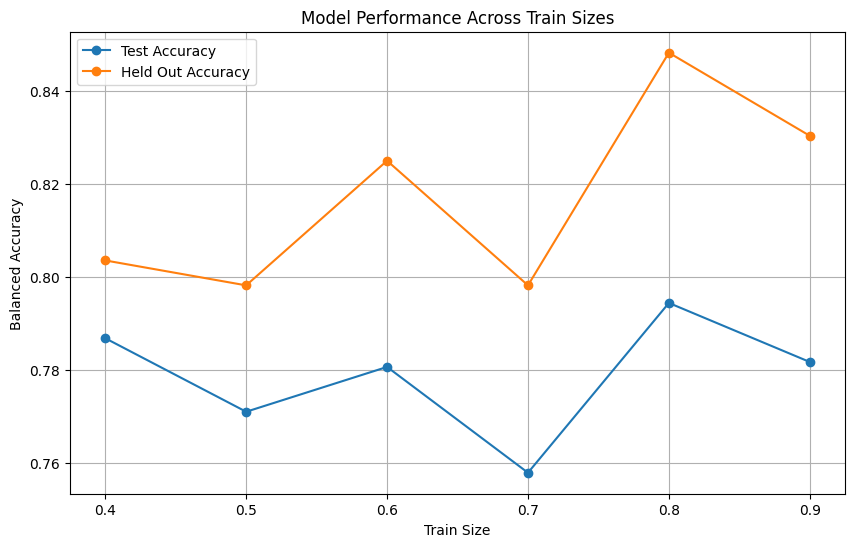

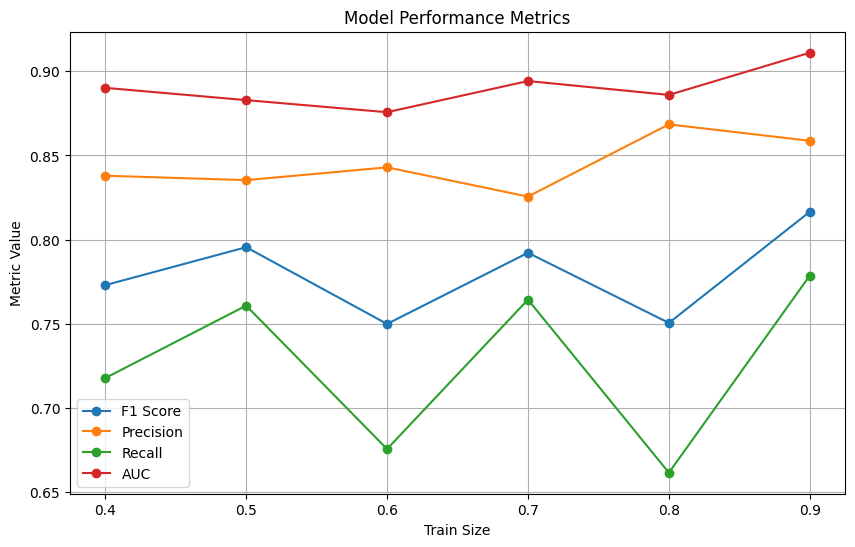

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert REF_ac dictionary into a DataFrame
train_size = np.arange(0.4, 1, 0.1)  # Array of train sizes you used
metrics = ['train', 'test', 'held out', 'f1', 'p', 'r', 'auc']

# Initialize an empty list to store the results
result_data = []

for i, s in enumerate(train_size):
    # Compute mean and std for each metric
    train_mean = np.mean(REF_ac['train'][i])
    train_std = np.std(REF_ac['train'][i])

    test_mean = np.mean(REF_ac['test'][i])
    test_std = np.std(REF_ac['test'][i])

    held_mean = np.mean(REF_ac['held out'][i])
    held_std = np.std(REF_ac['held out'][i])

    f1_mean = np.mean(REF_ac['f1'][i])
    f1_std = np.std(REF_ac['f1'][i])

    p_mean = np.mean(REF_ac['p'][i])
    p_std = np.std(REF_ac['p'][i])

    r_mean = np.mean(REF_ac['r'][i])
    r_std = np.std(REF_ac['r'][i])

    auc_mean = np.mean(REF_ac['auc'][i])
    auc_std = np.std(REF_ac['auc'][i])

    # Append the data for the current train size
    result_data.append([s, train_mean, train_std, test_mean, test_std, held_mean, held_std, f1_mean, f1_std, p_mean, p_std, r_mean, r_std, auc_mean, auc_std])

# Create a DataFrame
results_df = pd.DataFrame(result_data, columns=[
    'Train Size', 'Train Mean', 'Train Std',
    'Test Mean', 'Test Std', 'Held Out Mean', 'Held Out Std',
    'F1 Mean', 'F1 Std', 'Precision Mean', 'Precision Std',
    'Recall Mean', 'Recall Std', 'AUC Mean', 'AUC Std'
])

# Display the results
print(results_df)

# Optionally, you can plot the results to visualize progress
plt.figure(figsize=(10, 6))

# Plot train vs. test vs. held out accuracies
plt.plot(train_size, results_df['Test Mean'], label='Test Accuracy', marker='o')
plt.plot(train_size, results_df['Held Out Mean'], label='Held Out Accuracy', marker='o')

plt.xlabel('Train Size')
plt.ylabel('Balanced Accuracy')
plt.title('Model Performance Across Train Sizes')
plt.legend()
plt.grid(True)
plt.show()

# Plot F1 score, Precision, Recall, and AUC for comparison
plt.figure(figsize=(10, 6))

plt.plot(train_size, results_df['F1 Mean'], label='F1 Score', marker='o')
plt.plot(train_size, results_df['Precision Mean'], label='Precision', marker='o')
plt.plot(train_size, results_df['Recall Mean'], label='Recall', marker='o')
plt.plot(train_size, results_df['AUC Mean'], label='AUC', marker='o')

plt.xlabel('Train Size')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics')
plt.legend()
plt.grid(True)
plt.show()


These plots show averages of the 10 splits (cross-validation runs) for each of the 6 train_size values. Each train_size value represents the proportion of data used for training, meaning that as train_size increases, more data is used for training and less for testing. This setup helps visualize how model performance changes as the training data size increases. They may show overfitting if too much data is used in training and thus a reduction in test performance will be seen.

Note that balanced accuracy went down when we went from 80% training to 90% training. But look at the recall, it went down badly at 80% so taking that into account the 90% training might be the best.

Note also that the held out set is taken out early and doesn't change within the training set size looping.

Precision asks of the predicted positives, how many are correct? It is the positive predictive value of the model.

Recall is the same as sensitivity and asks of the actual positives how many were detected?

They don't include a specificity metric in their code which seams common in chemistry papers altough not common in computational toxicology papers.